# Baseline Unbalanced Model

This notebook trains the baseline EfficientNetB2 model on the unbalanced dataset without any class balancing techniques.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB2
from pathlib import Path
import json
import cv2
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.mixed_precision import set_global_policy

set_global_policy('mixed_float16')


2026-03-04 16:28:57.116666: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 16:28:57.645821: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 16:29:07.897413: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
PROJECT_ROOT = Path("../").resolve()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed" / "classification"
ORGANIZED_DIR = DATA_DIR / "organized"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models" / "baseline_unbalanced"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

with open(PROJECT_ROOT / "config.json", "r") as f:
    CONFIG = json.load(f)

## 1. Load Data


In [3]:
IMG_SIZE = 256
BATCH_SIZE = 64
NUM_CLASSES = 8

CLASS_NAMES = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']

# Load training data
train_dir = ORGANIZED_DIR / "train"

train_ds = keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds = keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int'
)
class_names = train_ds.class_names

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .cache()
    .shuffle(2000)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .cache()
    .prefetch(AUTOTUNE)
)

print(f"\nTraining batches: {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")
print(f"Class names: {class_names}")

Found 7010 files belonging to 7 classes.
Using 5608 files for training.


I0000 00:00:1772641775.847066  128053 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13685 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 7010 files belonging to 7 classes.
Using 1402 files for validation.

Training batches: 88
Validation batches: 22
Class names: ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']


## 2. Build Model

Create the EfficientNetB2 model with data augmentation.

In [4]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [5]:
def build_model():
    """Build EfficientNetB2 model with augmentation."""

    # Data augmentation
    img_augmentation = keras.Sequential(
        [
            layers.RandomRotation(factor=0.15),
            layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
            layers.RandomFlip(),
            layers.RandomContrast(factor=0.1),
        ],
        name="img_augmentation",
    )

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = img_augmentation(inputs)

    # EfficientNetB2 base
    base_model = EfficientNetB2(
        include_top=False,
        input_tensor=x,
        weights="imagenet"
    )
    base_model.trainable = False

    # Classification head
    x = layers.GlobalAveragePooling2D(name="avg_pool")(base_model.output)
    x = layers.Dropout(0.2, name="top_dropout")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="pred")(x)

    model = keras.Model(inputs, outputs, name="EfficientNet_Baseline")
    return model, base_model

model, base_model = build_model()
model.summary()

2026-03-04 16:29:42.995412: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Model: "EfficientNet_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_augmentation    │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 256, 256,  │          0 │ img_augmentation… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 256, 256,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 256, 256,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 257, 257,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 128, 128,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 128, 128,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 128, 128,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 128, 128,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 128, 128,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 128, 128,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 128, 128,  │          0 │ block1a_activati

 Total params: 7,779,841 (29.68 MB)

 Trainable params: 11,272 (44.03 KB)

 Non-trainable params: 7,768,569 (29.63 MB)

## 3. Phase 1: Feature Extraction

Train with frozen base model (higher learning rate).

In [6]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs detected:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
import tensorflow as tf

tf.debugging.set_log_device_placement(True)

In [8]:
# Compile for Phase 1
optimizer = keras.optimizers.Adam(learning_rate=1e-2)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(MODELS_DIR / 'phase1_best.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Phase 1: Feature Extraction")
print("Training classification head only...")

history1 = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks
)

Phase 1: Feature Extraction
Training classification head only...
Epoch 1/20


2026-03-04 16:30:07.948745: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.6303 - loss: 1.2909
Epoch 1: val_accuracy improved from None to 0.69330, saving model to  models/baseline_unbalanced/phase1_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 56s 352ms/step - accuracy: 0.6641 - loss: 1.1192 - val_accuracy: 0.6933 - val_loss: 0.9483 - learning_rate: 0.0100
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.7023 - loss: 0.8407
Epoch 2: val_accuracy did not improve from 0.69330
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 218ms/step - accuracy: 0.7054 - loss: 0.8441 - val_accuracy: 0.6897 - val_loss: 0.8349 - learning_rate: 0.0100
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.7138 - loss: 0.8234
Epoch 3: val_accuracy did not improve from 0.69330
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 216ms/step - accuracy: 0.7067 - loss: 0.8452 - val_accuracy: 0.6869 - val_loss: 0.9262 - learning_rate: 0.0100
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.7153 - loss: 0.7866
Epoch 4: val_accuracy improved from 0.69330 to 0.69829, saving model to  models/baseline_unbalanced/phase1_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 223ms/step - accuracy: 0.7163 - loss: 0.7982 - val_accuracy: 0.6983 - val_loss: 0.8565 - learning_rate: 0.0100
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.7118 - loss: 0.8069
Epoch 5: val_accuracy improved from 0.69829 to 0.71327, saving model to  models/baseline_unbalanced/phase1_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 224ms/step - accuracy: 0.7168 - loss: 0.8049 - val_accuracy: 0.7133 - val_loss: 0.8109 - learning_rate: 0.0100
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.7306 - loss: 0.7669
Epoch 6: val_accuracy improved from 0.71327 to 0.72040, saving model to  models/baseline_unbalanced/phase1_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 223ms/step - accuracy: 0.7216 - loss: 0.7865 - val_accuracy: 0.7204 - val_loss: 0.7985 - learning_rate: 0.0100
Epoch 7/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.7179 - loss: 0.7755
Epoch 7: val_accuracy did not improve from 0.72040
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 217ms/step - accuracy: 0.7154 - loss: 0.7952 - val_accuracy: 0.6776 - val_loss: 0.9014 - learning_rate: 0.0100
Epoch 8/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.7145 - loss: 0.7807
Epoch 8: val_accuracy did not improve from 0.72040
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 216ms/step - accuracy: 0.7227 - loss: 0.7773 - val_accuracy: 0.6997 - val_loss: 0.9042 - learning_rate: 0.0100
Epoch 9/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.7300 - loss: 0.7792
Epoch 9: val_accuracy did not improve from 0.72040
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 216ms/step - accuracy: 0.7233 - loss: 0.7867 - val_accuracy: 0.7197 - val_loss: 0.8164 - learning_rate: 0.0100
Epoch 10/20
88/88 ━━━

88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 224ms/step - accuracy: 0.7384 - loss: 0.7108 - val_accuracy: 0.7233 - val_loss: 0.8013 - learning_rate: 0.0050
Epoch 16/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.7490 - loss: 0.6822
Epoch 16: val_accuracy did not improve from 0.72325

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 217ms/step - accuracy: 0.7504 - loss: 0.6810 - val_accuracy: 0.7161 - val_loss: 0.8998 - learning_rate: 0.0050
Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 6.


## 4. Phase 2: Fine-Tuning

Unfreeze all layers and continue training with lower learning rate.

In [9]:
# Unfreeze base model
base_model.trainable = True

# Recompile with lower learning rate
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Update callbacks for Phase 2
callbacks[1] = keras.callbacks.ModelCheckpoint(
    filepath=str(MODELS_DIR / 'final_best.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("Phase 2: Fine-Tuning")
print("Training all layers...")

history2 = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=callbacks,
    initial_epoch=len(history1.history['loss'])
)

Phase 2: Fine-Tuning
Training all layers...
Epoch 17/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.7462 - loss: 0.7096
Epoch 17: val_accuracy improved from None to 0.72111, saving model to  models/baseline_unbalanced/final_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 30s 252ms/step - accuracy: 0.7411 - loss: 0.7065 - val_accuracy: 0.7211 - val_loss: 0.7879 - learning_rate: 1.0000e-04
Epoch 18/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.7343 - loss: 0.7147
Epoch 18: val_accuracy did not improve from 0.72111
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 217ms/step - accuracy: 0.7416 - loss: 0.6987 - val_accuracy: 0.7147 - val_loss: 0.7859 - learning_rate: 1.0000e-04
Epoch 19/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.7519 - loss: 0.6807
Epoch 19: val_accuracy did not improve from 0.72111
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 218ms/step - accuracy: 0.7411 - loss: 0.7040 - val_accuracy: 0.7183 - val_loss: 0.7846 - learning_rate: 1.0000e-04
Epoch 20/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.7386 - loss: 0.6984
Epoch 20: val_accuracy did not improve from 0.72111
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 217ms/step - accuracy: 0.7461 - loss: 0.6910 - val_accuracy: 0.7183 - val_loss: 0.7829 - learning_rate: 1.0000e-04

88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 225ms/step - accuracy: 0.7523 - loss: 0.6803 - val_accuracy: 0.7233 - val_loss: 0.7665 - learning_rate: 1.0000e-04
Epoch 27/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.7497 - loss: 0.6698
Epoch 27: val_accuracy improved from 0.72325 to 0.72468, saving model to  models/baseline_unbalanced/final_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 222ms/step - accuracy: 0.7471 - loss: 0.6828 - val_accuracy: 0.7247 - val_loss: 0.7691 - learning_rate: 1.0000e-04
Epoch 28/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.7517 - loss: 0.6550
Epoch 28: val_accuracy did not improve from 0.72468
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 217ms/step - accuracy: 0.7527 - loss: 0.6670 - val_accuracy: 0.7225 - val_loss: 0.7679 - learning_rate: 1.0000e-04
Epoch 29/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.7453 - loss: 0.6690
Epoch 29: val_accuracy did not improve from 0.72468
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 218ms/step - accuracy: 0.7448 - loss: 0.6858 - val_accuracy: 0.7225 - val_loss: 0.7649 - learning_rate: 1.0000e-04
Epoch 30/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.7394 - loss: 0.6996
Epoch 30: val_accuracy did not improve from 0.72468
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 217ms/step - accuracy: 0.7489 - loss: 0.6816 - val_accuracy: 0.7233 - val_loss: 0.7648 - learning_rate: 1.0000e-04

## 5. Save Final Model

Save the complete trained model.

In [10]:
# Save final model
model.save(MODELS_DIR / 'efficientnet_baseline_final.h5')
print(f"Model saved to: {MODELS_DIR / 'efficientnet_baseline_final.h5'}")

# Save training history
history_combined = {
    'loss': history1.history['loss'] + history2.history['loss'],
    'accuracy': history1.history['accuracy'] + history2.history['accuracy'],
    'val_loss': history1.history['val_loss'] + history2.history['val_loss'],
    'val_accuracy': history1.history['val_accuracy'] + history2.history['val_accuracy']
}

np.save(MODELS_DIR / 'training_history.npy', history_combined)
print("Training history saved.")

Model saved to:  models/baseline_unbalanced/efficientnet_baseline_final.h5
Training history saved.


## 6. Training History Visualization

Plot training and validation metrics.

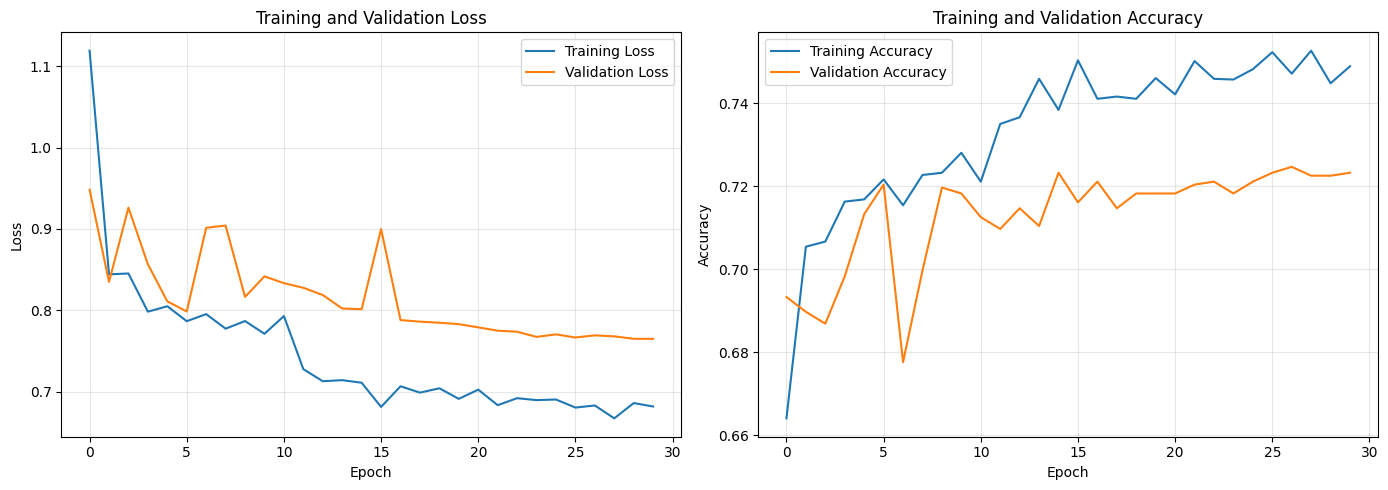

Final Training Accuracy: 0.7489
Final Validation Accuracy: 0.7233


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_combined['loss'], label='Training Loss')
axes[0].plot(history_combined['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_combined['accuracy'], label='Training Accuracy')
axes[1].plot(history_combined['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy: {history_combined['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_combined['val_accuracy'][-1]:.4f}")

## 7. Evaluation on Test Set

Load test data and evaluate model performance.

In [12]:
# Load test data
test_dir = ORGANIZED_DIR / "test"

test_ds = keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

# Get predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Found 1503 files belonging to 7 classes.
Classification Report:
              precision    recall  f1-score   support

       AKIEC       0.50      0.10      0.17        49
         BCC       0.73      0.21      0.32        77
         BKL       0.55      0.39      0.45       165
          DF       0.09      0.24      0.13        17
         MEL       0.46      0.30      0.36       167
          NV       0.81      0.95      0.87      1006
        VASC       0.73      0.50      0.59        22

    accuracy                           0.74      1503
   macro avg       0.55      0.38      0.41      1503
weighted avg       0.72      0.74      0.71      1503



2026-03-04 16:41:18.740689: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 8. Confusion Matrix

Visualize prediction patterns.

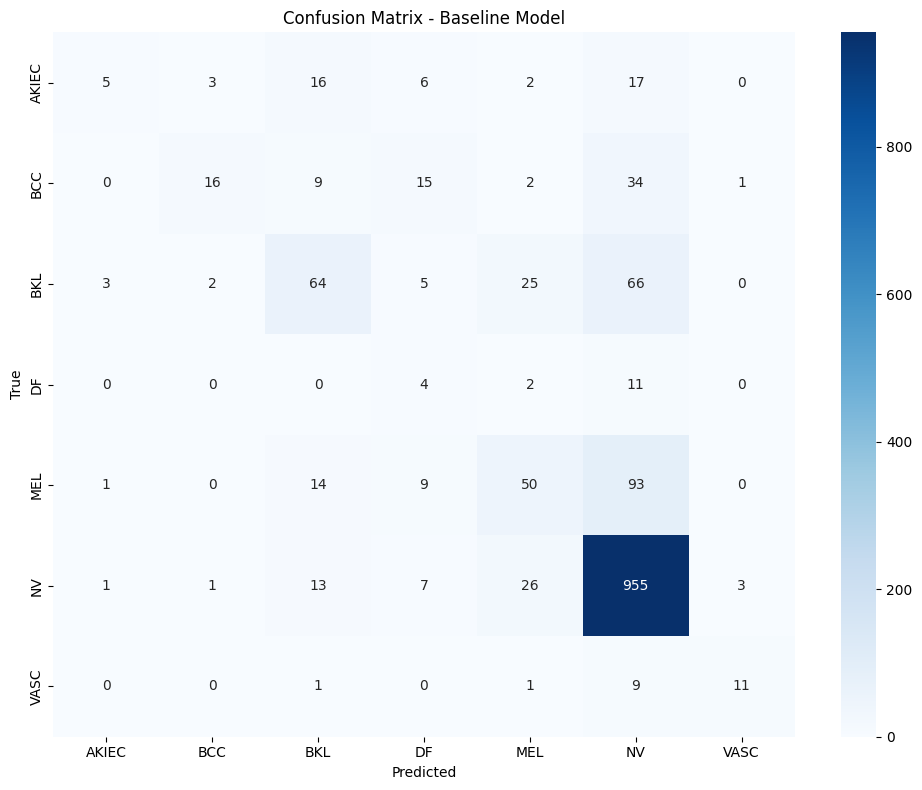

In [13]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Baseline Model')
plt.tight_layout()
plt.show()

## 9. Per-Class Accuracy Analysis

Analyze how the model performs on each class, especially minority classes.

Per-Class Performance:
Class  Total_Images  Correct_Predictions  Accuracy
AKIEC            49                    5  0.102041
  BCC            77                   16  0.207792
  BKL           165                   64  0.387879
   DF            17                    4  0.235294
  MEL           167                   50  0.299401
   NV          1006                  955  0.949304
 VASC            22                   11  0.500000


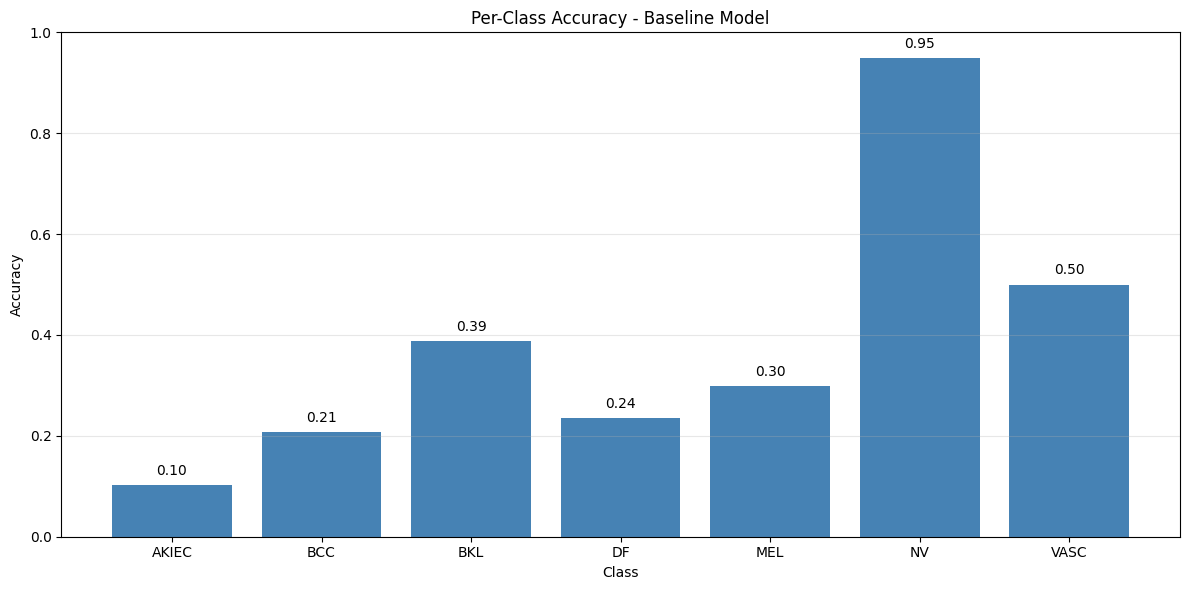


Results saved to:  results/baseline_results.csv


In [14]:
# Calculate per-class accuracy
class_correct = {cls: 0 for cls in CLASS_NAMES}
class_total = {cls: 0 for cls in CLASS_NAMES}

for true, pred in zip(y_true, y_pred):
    true_class = CLASS_NAMES[true]
    pred_class = CLASS_NAMES[pred]

    class_total[true_class] += 1
    if true == pred:
        class_correct[true_class] += 1

# Create results dataframe
results_df = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Total_Images': [class_total[cls] for cls in CLASS_NAMES],
    'Correct_Predictions': [class_correct[cls] for cls in CLASS_NAMES],
    'Accuracy': [class_correct[cls] / class_total[cls] if class_total[cls] > 0 else 0
                 for cls in CLASS_NAMES]
})

print("Per-Class Performance:")
print(results_df.to_string(index=False))

# Visualize
plt.figure(figsize=(12, 6))
plt.bar(results_df['Class'], results_df['Accuracy'], color='steelblue')
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy - Baseline Model')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
for i, (cls, acc) in enumerate(zip(results_df['Class'], results_df['Accuracy'])):
    plt.text(i, acc + 0.02, f'{acc:.2f}', ha='center')
plt.tight_layout()
plt.show()

# Save results
results_df.to_csv(RESULTS_DIR / 'baseline_results.csv', index=False)
print(f"\nResults saved to: {RESULTS_DIR / 'baseline_results.csv'}")